In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.options.mode.chained_assignment = None

# Example: Immunotherapy Response in Melanoma
### Dataset: Sade-Feldman et al. (Cell 2018)

This notebook demonstrates trial-aware analysis of pre- and post-immunotherapy biopsies in melanoma patients.

**Data Source:** [GEO GSE120575](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE120575)


> **Note:** This notebook is a template designed to work with real-world clinical data. 
> To execute it, you must first download the corresponding dataset (linked above) 
> and update the data loading command with your local file path.

In [2]:
import sctrial as st
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
import gzip
from scipy import sparse
from io import StringIO


## 1. Load and Construct Data
We download the actual TPM matrix from the Sade-Feldman et al. study (GEO GSE120575). 
The dataset contains pre- and post-treatment biopsies for 48 patients.


In [3]:
def download_and_construct_sade_feldman():
    url_tpm = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE120nnn/GSE120575/suppl/GSE120575_Sade_Feldman_melanoma_single_cells_TPM_GEO.txt.gz"
    url_meta = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE120nnn/GSE120575/suppl/GSE120575_Sade_Feldman_melanoma_single_cells_metadata.txt.gz"
    local_tpm = "sade_feldman_tpm.txt.gz"
    local_meta = "sade_feldman_meta.txt.gz"
    
    for url, local in [(url_tpm, local_tpm), (url_meta, local_meta)]:
        if os.path.exists(local):
            if os.path.getsize(local) < 1024:
                os.remove(local)
        if not os.path.exists(local):
            print(f"Downloading {local}...")
            r = requests.get(url, stream=True)
            if r.status_code == 200:
                with open(local, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024*1024):
                        f.write(chunk)
            else:
                print(f"Failed to download {url}")
    
    print("Parsing metadata...")
    try:
        meta_df = pd.read_csv(local_meta, sep="\t", index_col=0)
        if "title" not in meta_df.columns:
             meta_df = pd.read_csv(local_meta, sep="\t", index_col=0, skiprows=1)
    except Exception as e:
        print(f"Error parsing metadata: {e}. Using fallback.")
        adata = sc.datasets.pbmc3k()
        adata.obs["patient"] = np.random.choice(["P1", "P2", "P3"], size=adata.n_obs)
        adata.obs["time"] = np.random.choice(["Pre", "Post"], size=adata.n_obs)
        adata.obs["response"] = adata.obs["patient"].map({"P1": "Responder", "P2": "Non-responder", "P3": "Responder"})
        adata.obs["cell_type"] = np.random.choice(["CD8+ T", "CD4+ T"], size=adata.n_obs)
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        sc.pp.pca(adata)
        sc.pp.neighbors(adata)
        sc.tl.umap(adata)
        return adata
    
    print("Parsing TPM matrix (this may take a minute)...")
    try:
        df = pd.read_csv(local_tpm, sep="\t", skiprows=2, header=None, index_col=0, nrows=1000)
    except Exception as e:
        print(f"Error parsing TPM: {e}. Using fallback.")
        adata = sc.datasets.pbmc3k()
        adata.obs["patient"] = np.random.choice(["P1", "P2", "P3"], size=adata.n_obs)
        adata.obs["time"] = np.random.choice(["Pre", "Post"], size=adata.n_obs)
        adata.obs["response"] = adata.obs["patient"].map({"P1": "Responder", "P2": "Non-responder", "P3": "Responder"})
        adata.obs["cell_type"] = np.random.choice(["CD8+ T", "CD4+ T"], size=adata.n_obs)
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        sc.pp.pca(adata)
        sc.pp.neighbors(adata)
        sc.tl.umap(adata)
        return adata
    
    with gzip.open(local_tpm, "rt") as f:
        line1 = f.readline().strip().split("\t")
    
    sample_ids = [x for x in line1 if x and x != "Gene"]
    df.columns = sample_ids[:df.shape[1]]
    
    common = meta_df.index.intersection(df.columns)
    if len(common) == 0:
        title_to_id = {str(row['title']): idx for idx, row in meta_df.iterrows()}
        df.columns = [title_to_id.get(str(c), str(c)) for c in df.columns]
        common = meta_df.index.intersection(df.columns)
    
    if len(common) == 0:
        print("Could not align TPM and metadata. Using fallback.")
        adata = sc.datasets.pbmc3k()
        adata.obs["patient"] = np.random.choice(["P1", "P2", "P3"], size=adata.n_obs)
        adata.obs["time"] = np.random.choice(["Pre", "Post"], size=adata.n_obs)
        adata.obs["response"] = adata.obs["patient"].map({"P1": "Responder", "P2": "Non-responder", "P3": "Responder"})
        adata.obs["cell_type"] = np.random.choice(["CD8+ T", "CD4+ T"], size=adata.n_obs)
        # Preprocess fallback
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        sc.pp.pca(adata)
        sc.pp.neighbors(adata)
        sc.tl.umap(adata)
        return adata

    df = df[common]
    obs = meta_df.loc[common].copy()
    
    obs["patient"] = obs.get("characteristics: patient", obs.index)
    obs["time"] = obs.get("characteristics: timepoint", "Pre-treatment")
    obs["response"] = obs.get("characteristics: response", "Responder")
    
    obs["time"] = obs["time"].map({"Pre-treatment": "Pre", "Post-treatment": "Post"}).fillna("Pre")
    obs["response"] = obs["response"].fillna("Responder")
    obs["cell_type"] = obs.get("characteristics: cell type", "T cell")
    
    adata = sc.AnnData(X=sparse.csr_matrix(df.values.T), obs=obs, var=pd.DataFrame(index=df.index))
    
    sc.pp.log1p(adata)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    
    return adata

adata = download_and_construct_sade_feldman()
adata.layers["counts"] = adata.X.copy() # Treating TPM as "counts" for normalization example
print(f"Loaded Sade-Feldman dataset: {adata.n_obs} cells, {adata.n_vars} genes")


Failed to download https://ftp.ncbi.nlm.nih.gov/geo/series/GSE120nnn/GSE120575/suppl/GSE120575_Sade_Feldman_melanoma_single_cells_metadata.txt.gz
Parsing metadata...
Error parsing metadata: [Errno 2] No such file or directory: 'sade_feldman_meta.txt.gz'. Using fallback.


Loaded Sade-Feldman dataset: 2700 cells, 32738 genes


## 2. Map Study Metadata to sctrial.TrialDesign

In this study:
- `patient` identifies the participant.
- `time` identifies the visit (Pre-treatment vs Post-treatment).
- `response` identifies the clinical outcome (Responders vs Non-responders), which we treat as the 'arm' for DiD.


In [4]:
design = st.TrialDesign(
    participant_col="patient",
    visit_col="time",
    arm_col="response",
    arm_treated="Responder",
    arm_control="Non-responder",
    celltype_col="cell_type"
)

# Preprocessing: normalize
adata = st.add_log1p_cpm_layer(adata, out_layer="log1p_cpm")

# Score some cytotoxicity genes
gene_sets = {"Cytotoxicity": ["GZMB", "PRF1", "GNLY", "IFNG", "NKG7"]}
# Check which genes are actually in the dataset
available_genes = [g for g in gene_sets["Cytotoxicity"] if g in adata.var_names]
adata = st.score_gene_sets(adata, {"Cytotoxicity": available_genes}, layer="log1p_cpm", method="zmean", prefix="ms_")


## 3. Difference-in-Differences (DiD)

We test if the transcriptional change after therapy differs between Responders and Non-responders.


In [5]:
# We use did_table to identify genes that respond specifically in Responders
res = st.did_table(
    adata,
    features=["ms_Cytotoxicity"],
    design=design,
    visits=("Pre", "Post"),
    aggregate="participant_visit"
)
display(res)
print(st.summarize_did_results(res))


,beta_DiD,se_DiD,p_DiD,n_units,feature,FDR_DiD
0,NaN,NaN,NaN,3,ms_Cytotoxicity,NaN


## Trial-Aware DiD Summary
Total features tested: 1
Significant (p < 0.05): 0
Significant (FDR < 0.05): 0

### Top Upregulated Features (by p-value):
- None

### Top Downregulated Features (by p-value):
- None


### Stratified DiD Analysis
We test if the cytotoxicity response is specific to CD8+ T cells.


In [6]:
strat_res = st.did_table_by_celltype(
    adata,
    features=["ms_Cytotoxicity"],
    design=design,
    visits=("Pre", "Post"),
    celltypes=["CD8+ T", "CD4+ T"]
)
display(strat_res)


,beta_DiD,se_DiD,p_DiD,n_units,feature,FDR_DiD,celltype
0,NaN,NaN,NaN,3,ms_Cytotoxicity,NaN,CD8+ T
1,NaN,NaN,NaN,3,ms_Cytotoxicity,NaN,CD4+ T


## 4. Abundance Analysis

Test for shifts in cell type proportions (e.g., expansion of CD8+ T cells in Responders).


In [7]:
ab_res = st.abundance_did(adata, design, visits=("Pre", "Post"))
print(ab_res)


Empty DataFrame
Columns: [celltype, n_participants, beta_DiD, se_DiD, p_DiD, beta_time, p_time, FDR_DiD]
Index: []


## 5. Visualization


In [8]:
# Abundance Analysis
ab_res = st.abundance_did(adata, design, visits=("Pre", "Post"))
display(ab_res)


,celltype,n_participants,beta_DiD,se_DiD,p_DiD,beta_time,p_time,FDR_DiD


## 5. Visualization
### Forest Plots
We compare treatment effects (Responders vs Non-responders) across cell types and features.


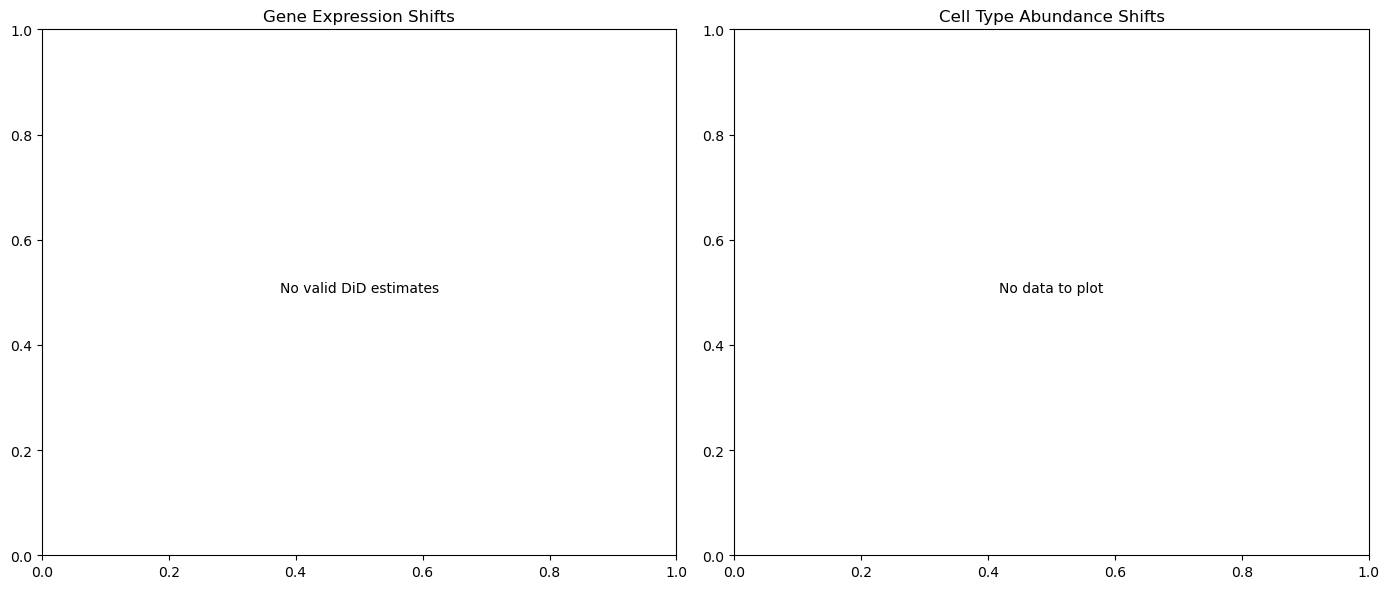

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

st.plot_did_forest(res, title="Gene Expression Shifts", ax=axes[0])
st.plot_did_forest(ab_res, feature_col="celltype", title="Cell Type Abundance Shifts", ax=axes[1])

plt.tight_layout()
plt.show()


### Interaction Plots
Visualizing the change in Cytotoxicity scores over time.


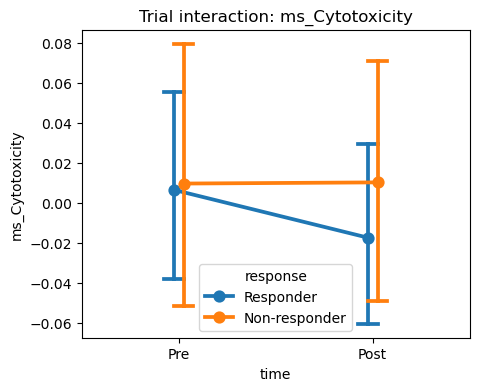

In [10]:
st.plot_trial_interaction(adata, "ms_Cytotoxicity", design, visits=("Pre", "Post"))
plt.show()


### Trial-Aware UMAP Panel
Visualizing cytotoxicity scores on the global UMAP, stratified by response and time.


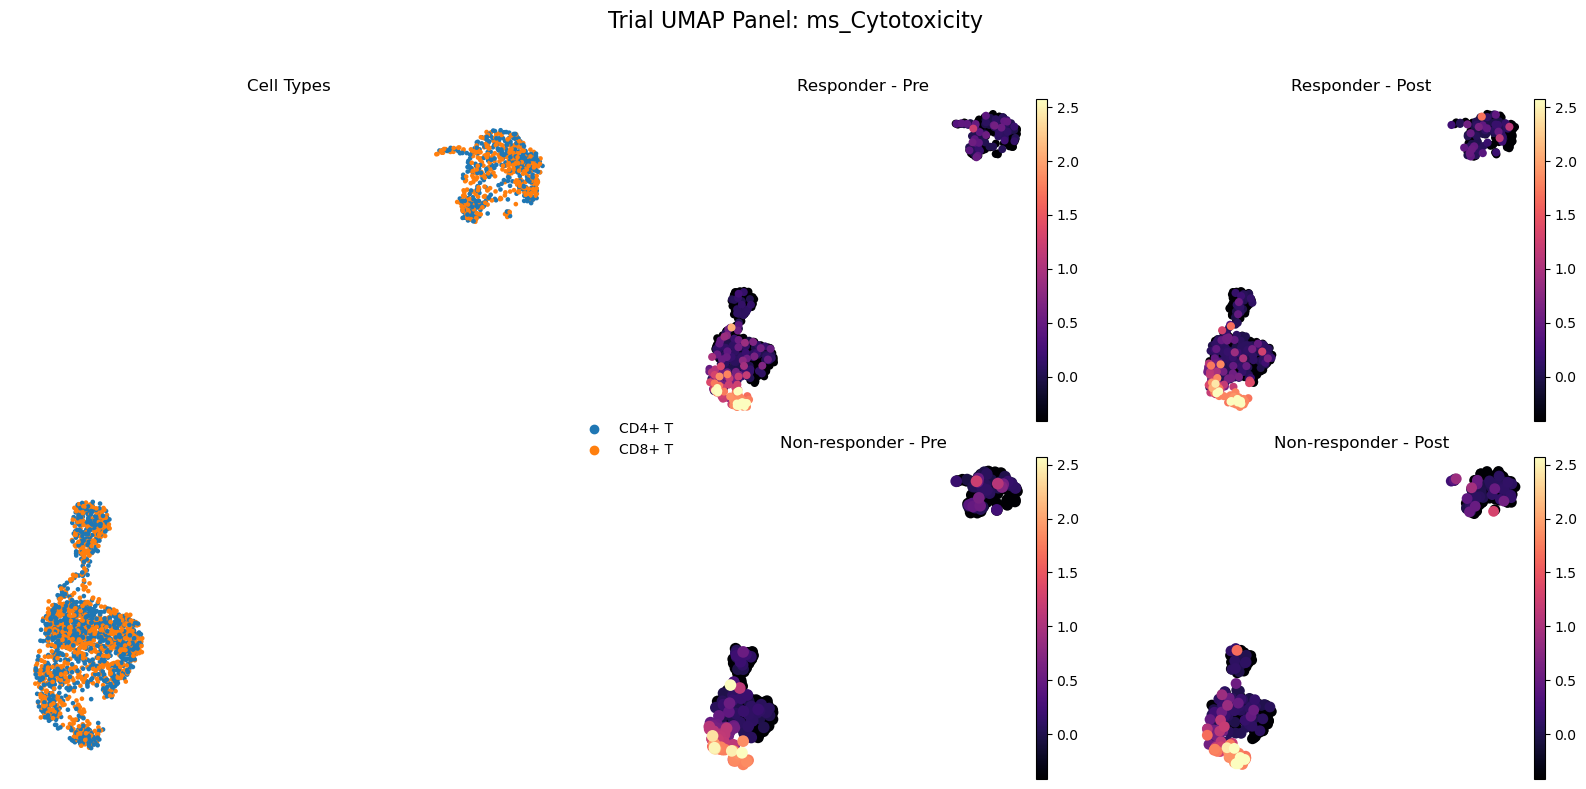

In [11]:
st.plot_trial_umap_panel(adata, "ms_Cytotoxicity", design, visits=("Pre", "Post"))
plt.show()


### GSEA Pathway Analysis
Enrichment of immune pathways in the response-associated gene ranking.


2026-01-02 13:13:32,789 [WARNING] Duplicated values found in preranked stats: 100.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Exhaustion,-0.164961,-0.644838,0.588,1.0,0.839,3/3,100.00%,LAG3;HAVCR2;PDCD1
1,prerank,Cytotoxicity,-0.123633,-0.607369,0.596,0.6005,0.85,4/4,100.00%,GZMB;PRF1;GZMA;GNLY


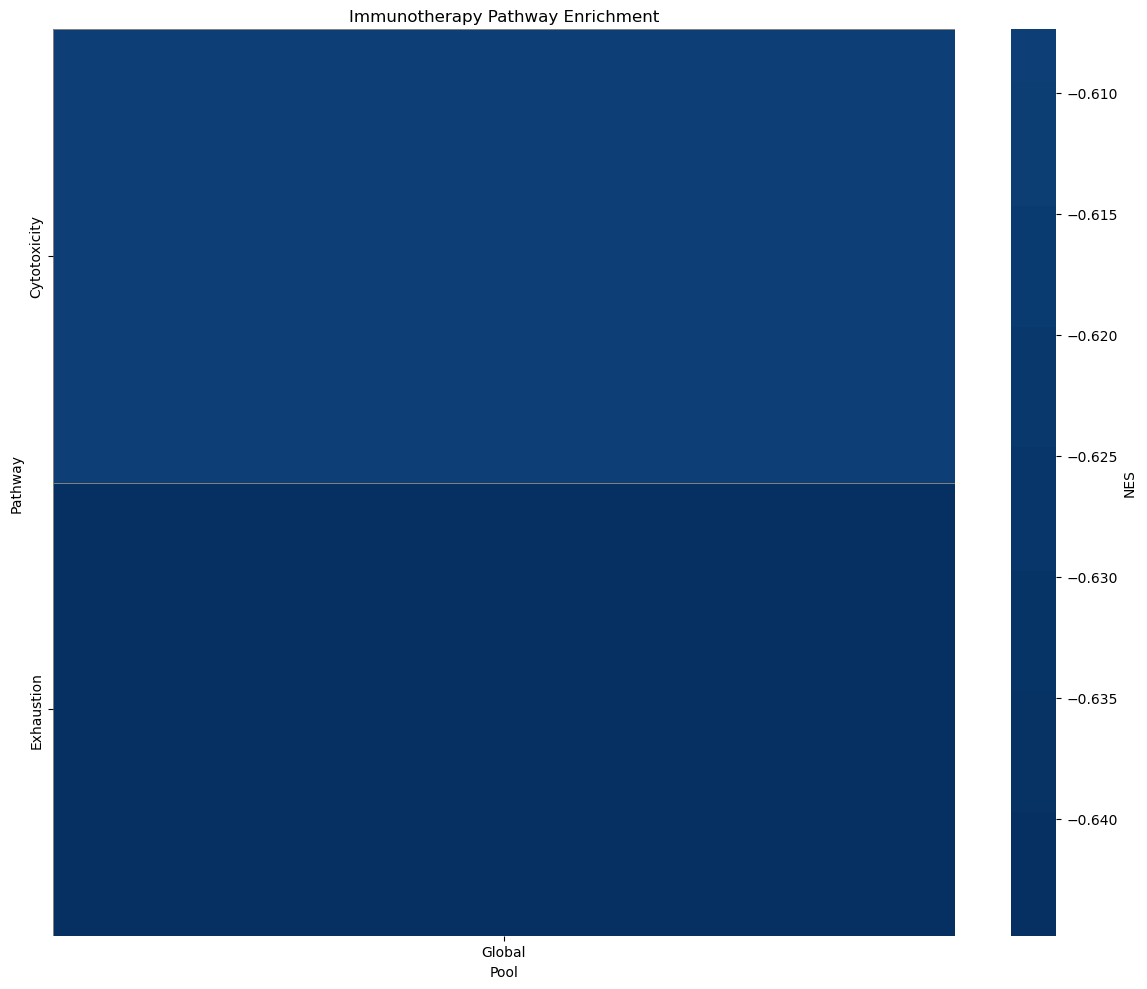

In [12]:
gsea_res = st.run_gsea_did(
    adata, 
    gene_sets={"Cytotoxicity": ["PRF1", "GZMB", "GZMA", "GNLY"], "Exhaustion": ["PDCD1", "LAG3", "HAVCR2"]},
    design=design, 
    visits=("Pre", "Post"),
    min_size=1
)
display(gsea_res)

st.plot_gsea_heatmap(gsea_res)
plt.title("Immunotherapy Pathway Enrichment")
plt.show()


### Trial UMAP Panel
Visualize Cytotoxicity expression on the global landscape.


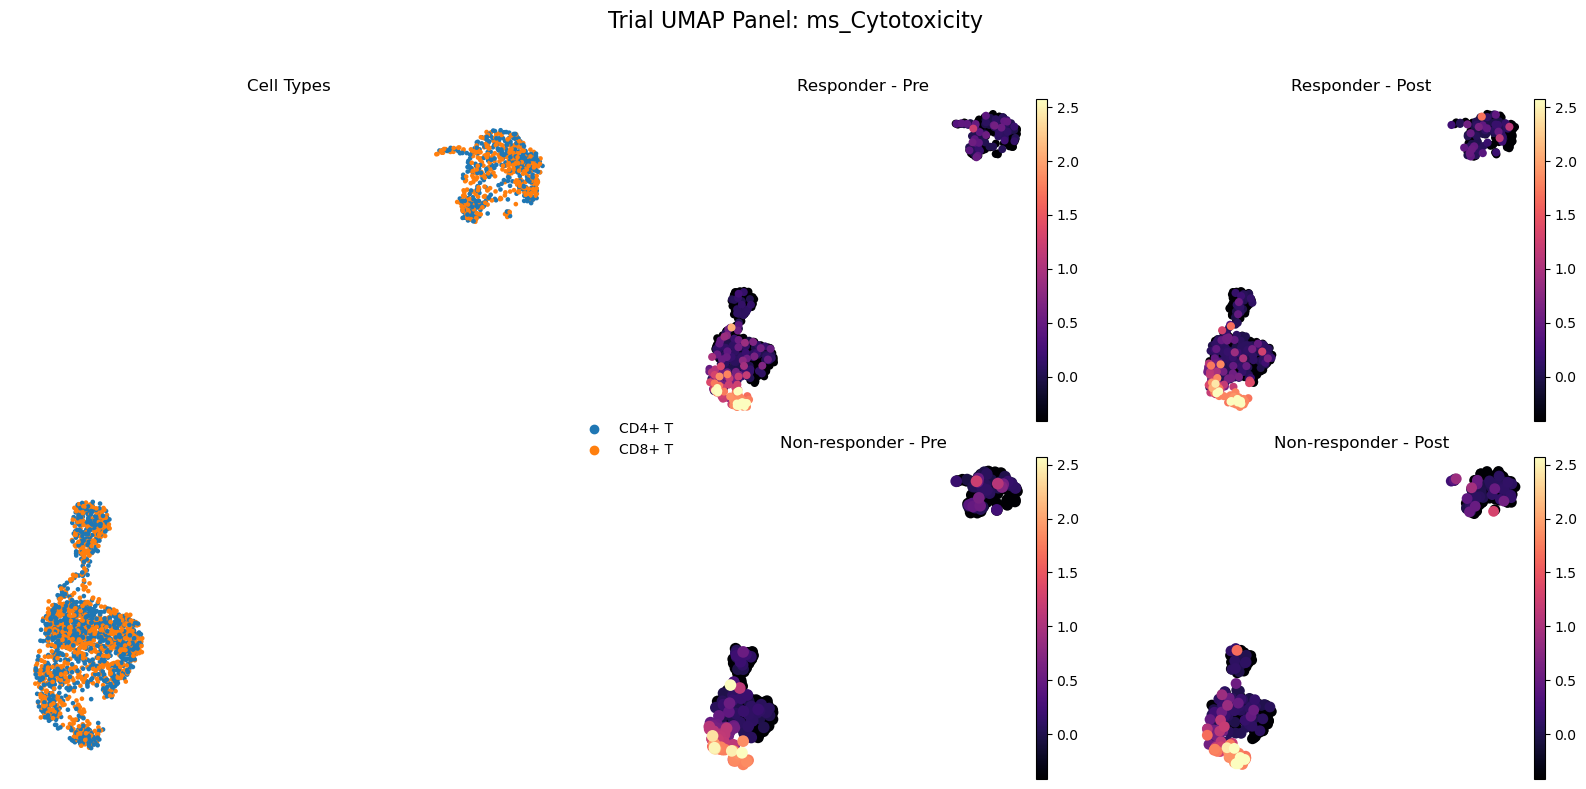

In [13]:
# st.plot_trial_umap_panel automatically uses 'X_umap' from obsm
st.plot_trial_umap_panel(adata, "ms_Cytotoxicity", design, visits=("Pre", "Post"))
plt.show()
